In [57]:
import numpy as np
import pandas as pd
import random
from chemevo import evolution_V1 as evo
import itertools
import make_models_script
import glob

import matplotlib.pyplot as plt
from matplotlib import rcParams


params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

In [58]:
mg_h_big_bin_edges = np.arange(-0.7, 0.50, 0.20) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])


In [59]:
summary_df = pd.read_csv("data_lines_with_vals.csv")

def compute_mn_fe_model(row, fe_centers):
    return (row['slope_mn_fe'] * fe_centers) + row['intercept_mn_fe']

summary_df['mn_fe_model_vals'] = summary_df.apply(
    lambda r: compute_mn_fe_model(r, fe_mg_centers).tolist(), axis=1
)

In [60]:
def plot_mn_fe(param_to_plot, models_files_dir):
    
    # 1. Read optimization history to find the final best_val
    history_path = f"{models_files_dir}/optimization_history.csv"
    history_df = pd.read_csv(history_path)
    
    best_val = None
    for index, row in history_df.iterrows():
        if row['optimized_param'] == param_to_plot:
            best_val = row['best_val']
    
    print(f"Extracted best_val for {param_to_plot}: {best_val}")

    # 2. Load the model files
    dfs = []
    plot_file_pattern = f"{models_files_dir}/{param_to_plot}_*"
    to_plot_files = glob.glob(plot_file_pattern)

    for path in to_plot_files:
        dfs.append(pd.read_csv(path))

    if not dfs:
        print("No data found.")
        return

    all_dfs = pd.concat(dfs, ignore_index=True)
    vmin = all_dfs[param_to_plot].min()
    vmax = all_dfs[param_to_plot].max()

    plt.figure(figsize=(20, 5))
    sc = None # Initialize to avoid errors if only the pink scatter plots

    # 3. Plotting loop
    for i in range(len(mg_h_big_bin_centers)):
        plt.subplot(1, 5, i + 1)
        
        for df in dfs:
            mask = np.isclose(df['mg_h_bin'], mg_h_big_bin_centers[i])
            subset = df[mask]
            
            if len(subset) == 0:
                continue

            val = subset[param_to_plot].iloc[0]
            
            if best_val is not None and np.isclose(val, best_val, rtol=1e-6):
                plt.scatter(subset['fe_mg'], subset['mn_fe'], alpha=0.8, color='pink', 
                            edgecolors='hotpink', label=f"{param_to_plot} = {val:.3f}", zorder=10)
            else:
                sc = plt.scatter(subset['fe_mg'], subset['mn_fe'], alpha=0.3, 
                                 label=f"{param_to_plot} = {val:.2f}", c=subset[param_to_plot], 
                                 cmap='viridis', vmin=vmin, vmax=vmax)
                
        # Plot summary data
        mask_data = np.isclose(summary_df['mg_h_bin_center'], mg_h_big_bin_centers[i])
        data_subset = summary_df[mask_data]

        if len(data_subset) > 0:
            plt.plot(fe_mg_centers, data_subset['mn_fe_model_vals'].iloc[0], color='black', marker='o', zorder=12)

        if i == 0:
            plt.ylabel('[Mn/Fe]')
            plt.legend(bbox_to_anchor=[-0.5, 1])

        plt.grid(True, alpha=0.3)
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.xlabel('[Fe/Mg]')

    if sc is not None:
        cbar = plt.colorbar(sc, ax=plt.gcf().axes)
        cbar.set_label(param_to_plot)
        
    plt.show()

# Models 3

 --alpha_cc 0.50 --alpha_Ia 0.80 --g_cc 0.40 --g_ratio 1.90 --save_dir "unity_models_3"

Extracted best_val for alpha_cc: 0.3399999999999999


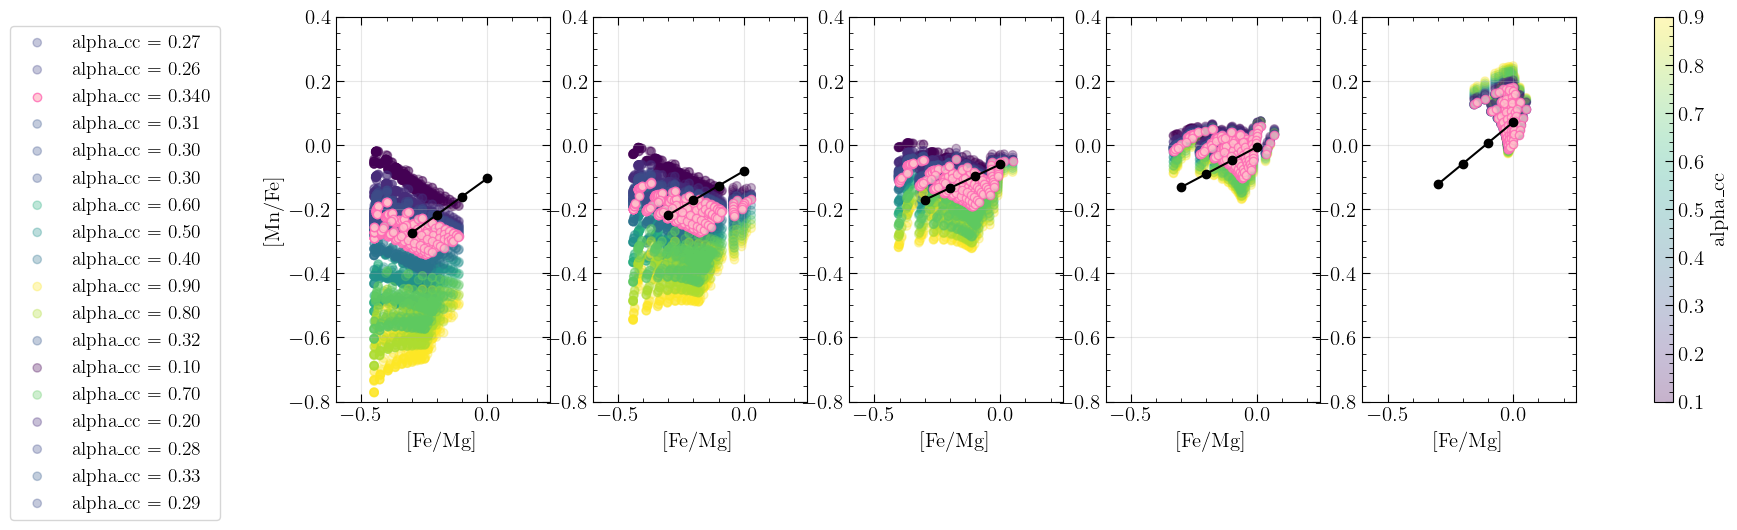

In [61]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="../outputs/unity_models_3")

Extracted best_val for alpha_Ia: 0.66


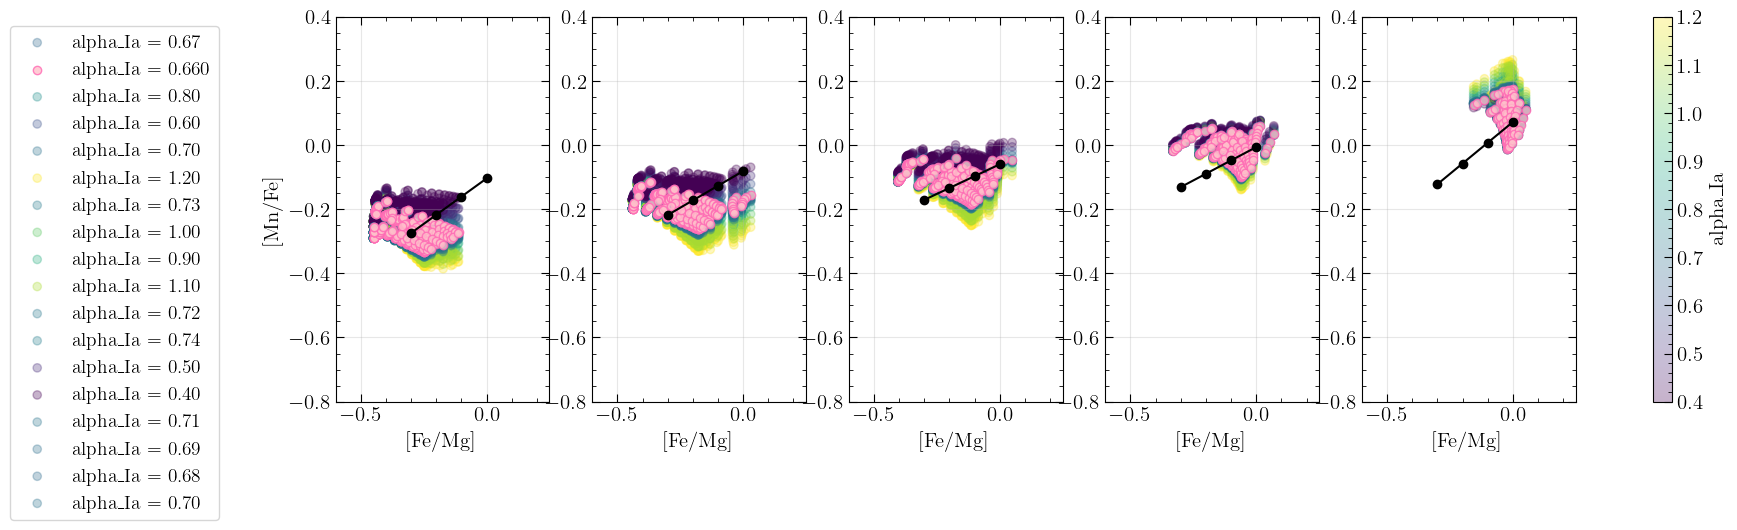

In [62]:
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="../outputs/unity_models_3")

Extracted best_val for g_cc: 0.39


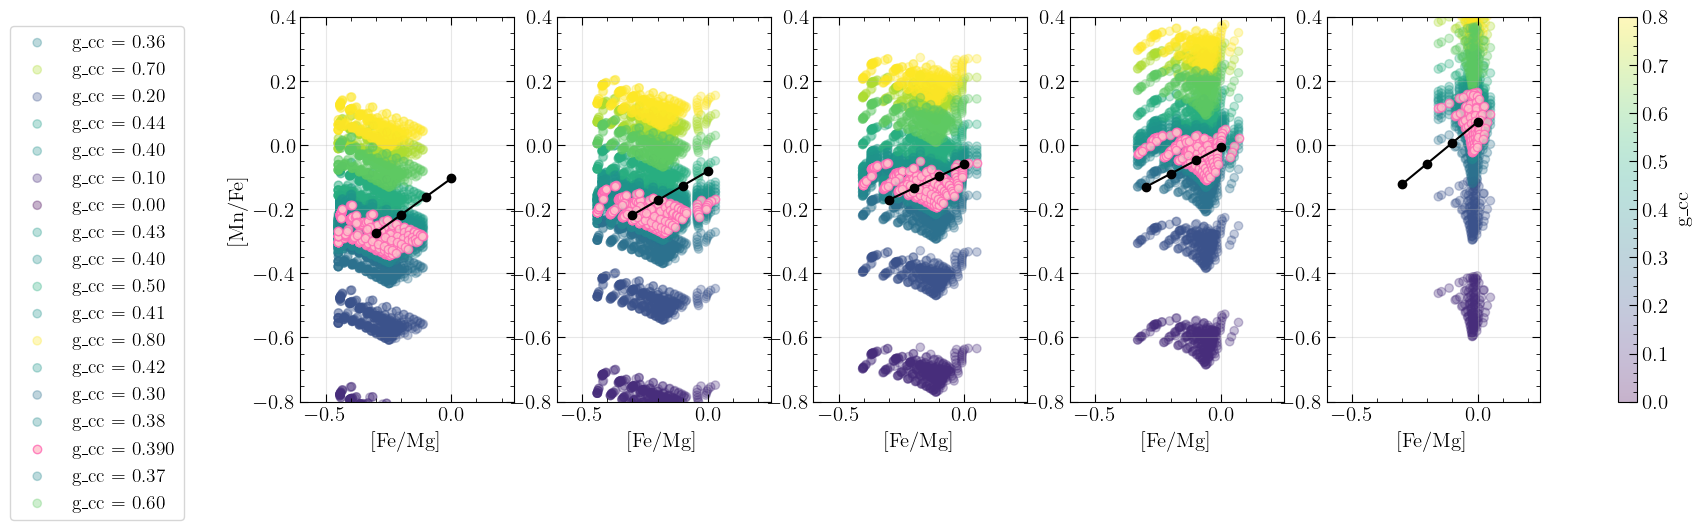

In [63]:
plot_mn_fe(param_to_plot="g_cc", models_files_dir="../outputs/unity_models_3")

Extracted best_val for g_ratio: 1.84


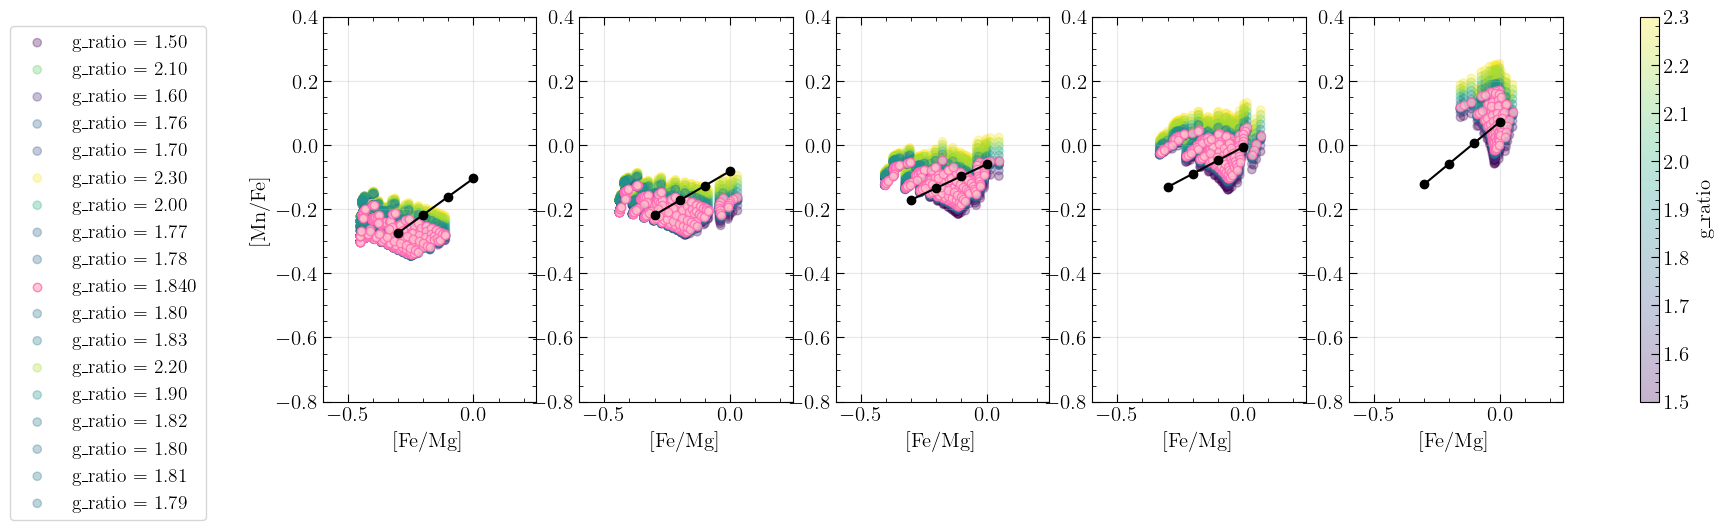

In [64]:
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="../outputs/unity_models_3")

# Models 4

--alpha_cc 0.50 --alpha_Ia 0.40 --g_cc 0.20 --g_ratio 1.90 --save_dir "unity_models_4"

Extracted best_val for alpha_cc: 0.0999999999999999


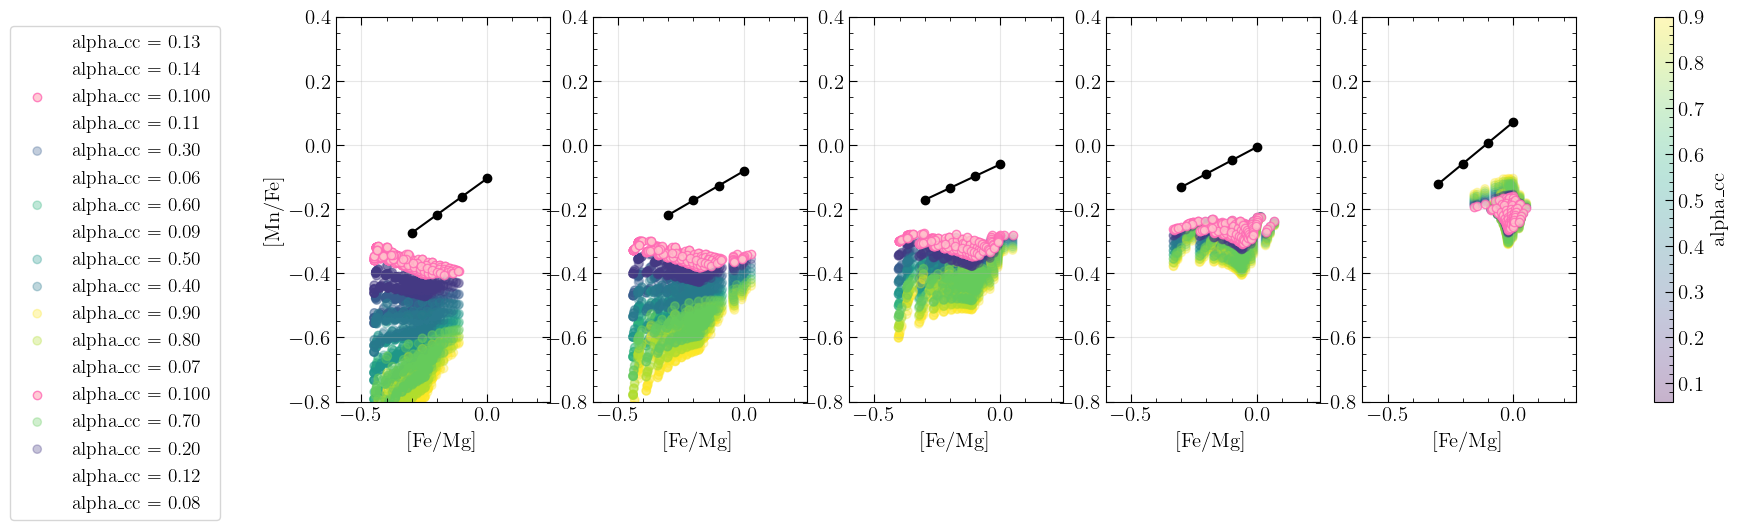

In [65]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="../outputs/unity_models_4")

Extracted best_val for alpha_Ia: 0.0199999999999999


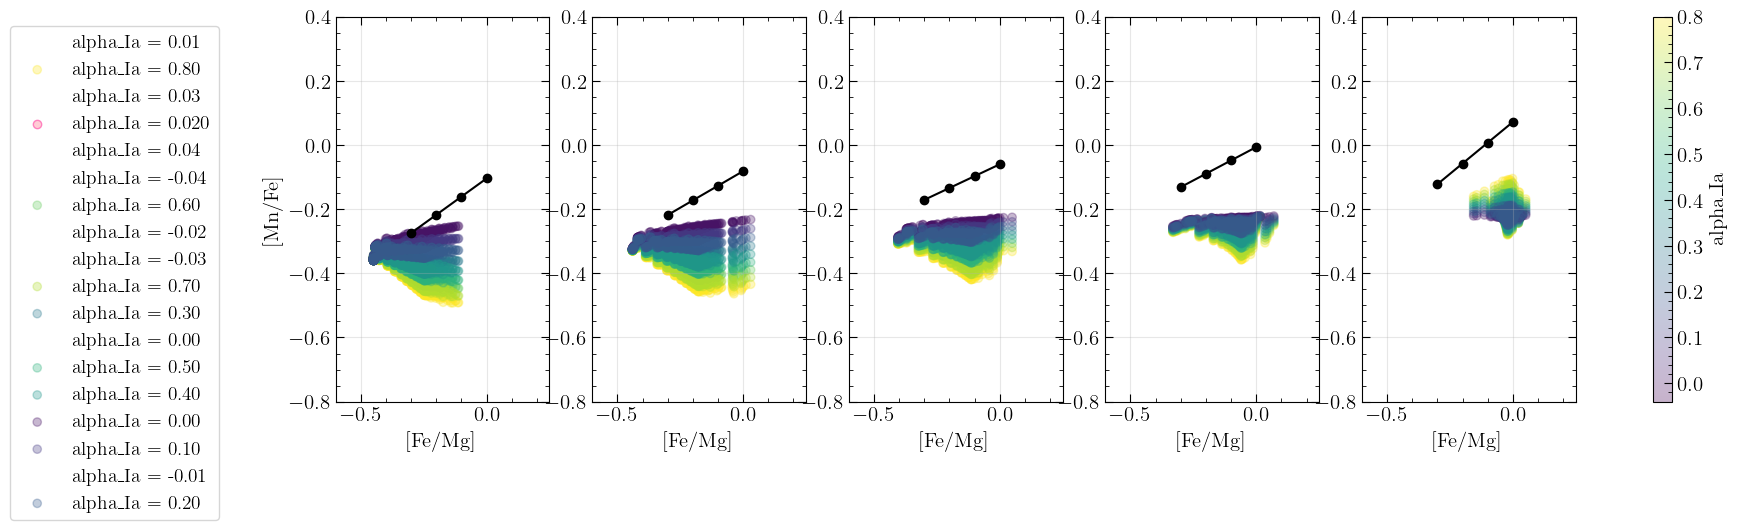

In [66]:
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="../outputs/unity_models_4")

Extracted best_val for g_cc: -0.07


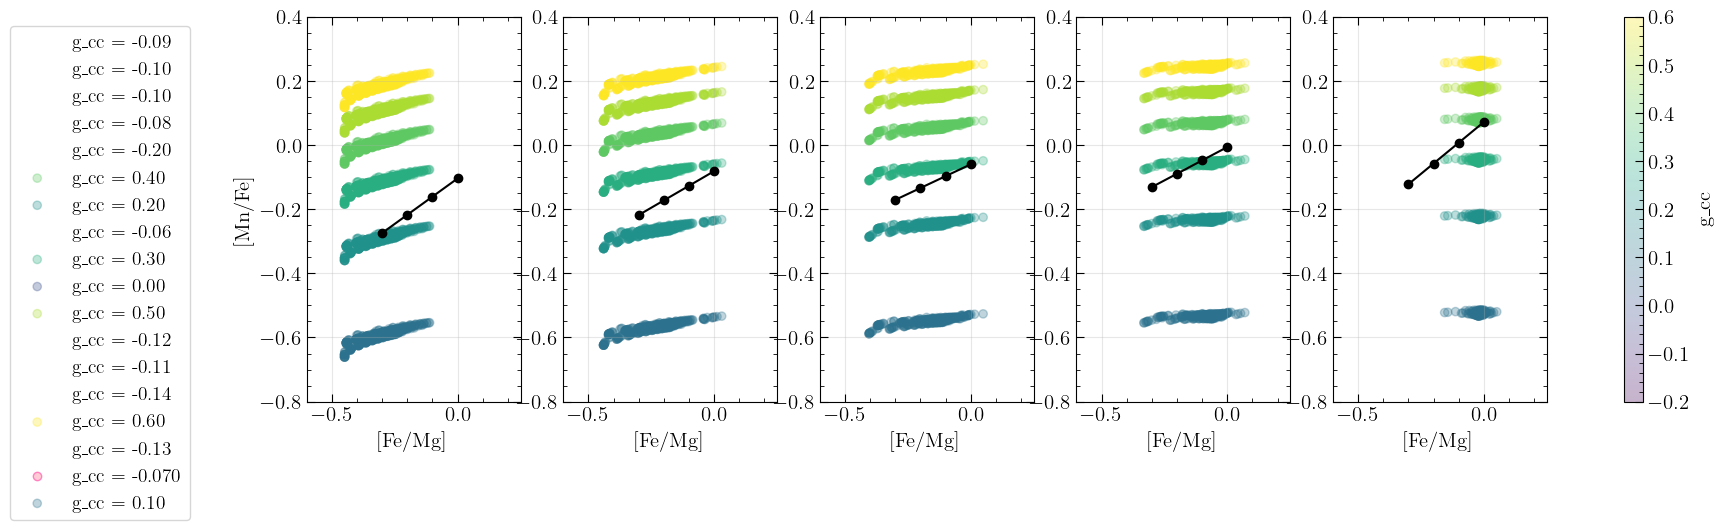

In [67]:
plot_mn_fe(param_to_plot="g_cc", models_files_dir="../outputs/unity_models_4")

Extracted best_val for g_ratio: 1.67


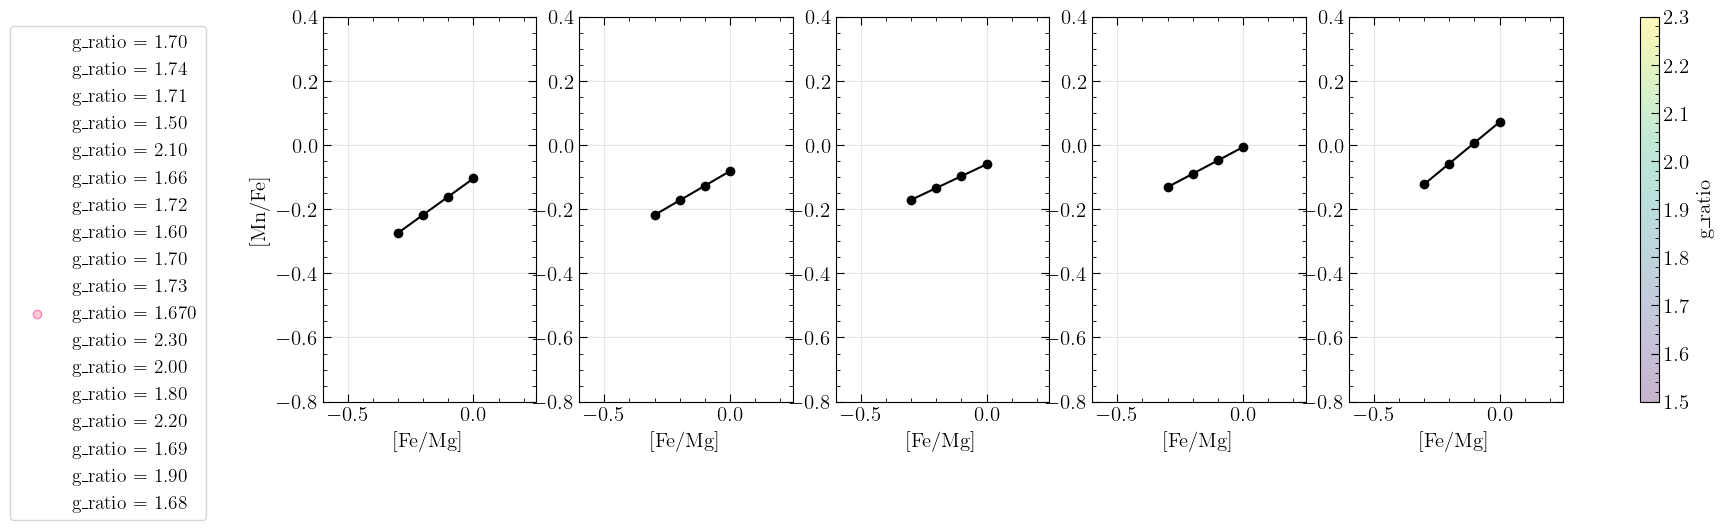

In [68]:
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="../outputs/unity_models_4")

# Models 5

 --alpha_cc 0.50 --alpha_Ia 0.40 --g_cc 0.80 --g_ratio 1.90 --save_dir "unity_models_5"

Extracted best_val for alpha_cc: 0.86


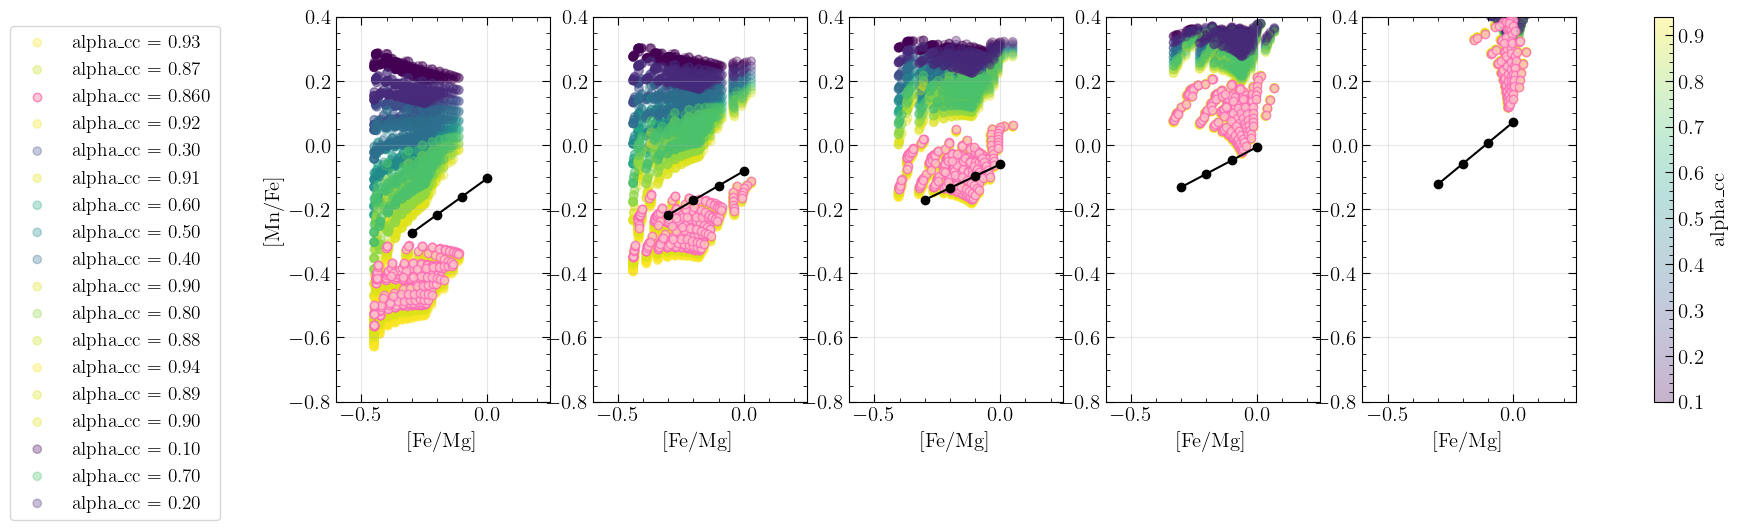

In [69]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="../outputs/unity_models_5")

Extracted best_val for alpha_Ia: 0.76


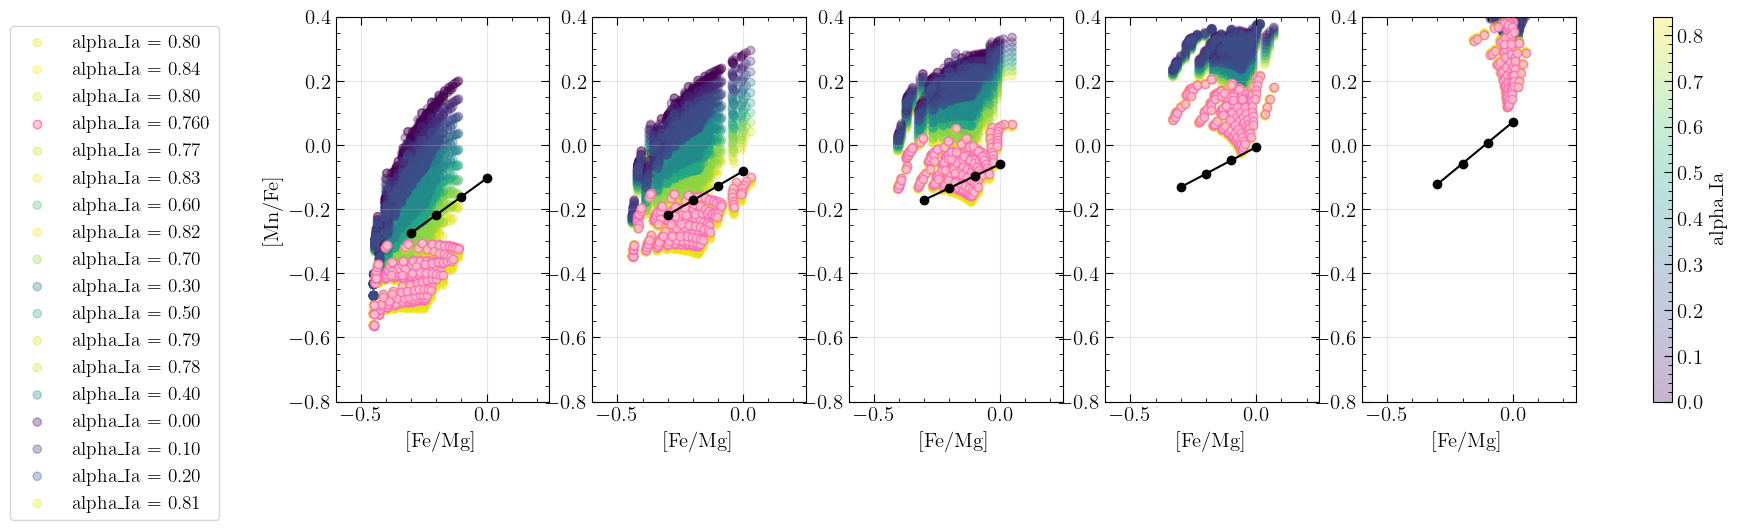

In [70]:
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="../outputs/unity_models_5")

Extracted best_val for g_cc: 0.6000000000000001


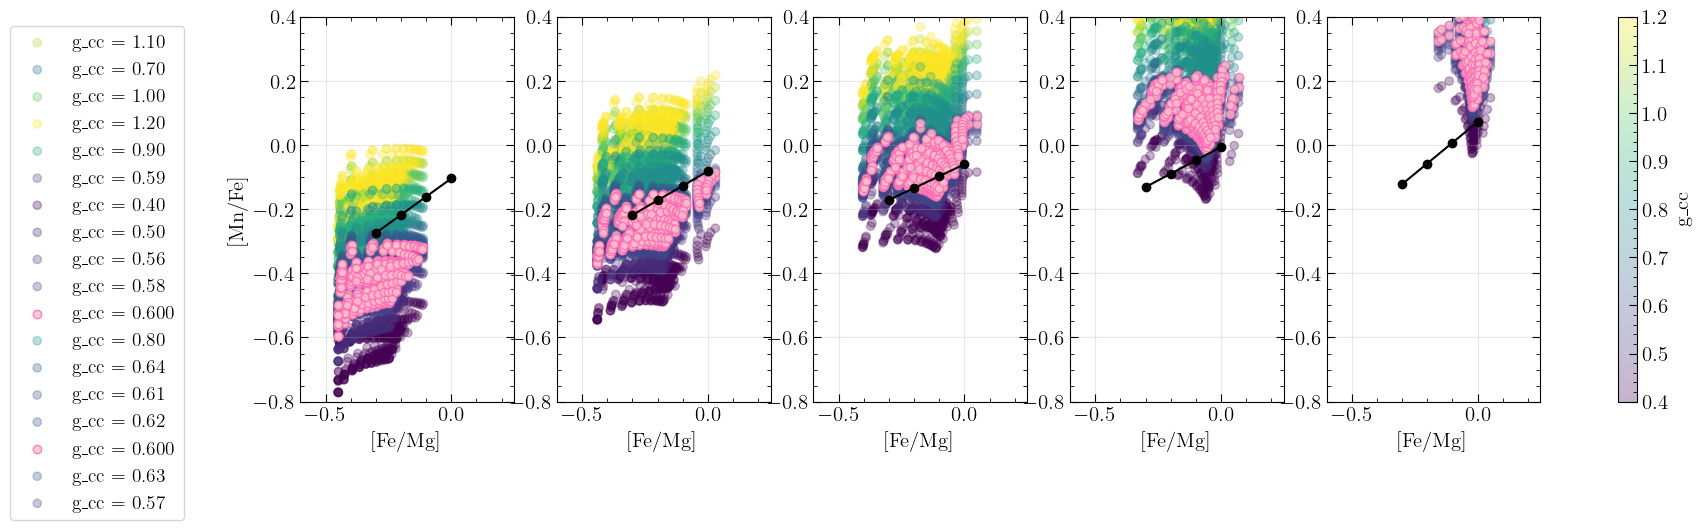

In [71]:
plot_mn_fe(param_to_plot="g_cc", models_files_dir="../outputs/unity_models_5")

Extracted best_val for g_ratio: 1.66


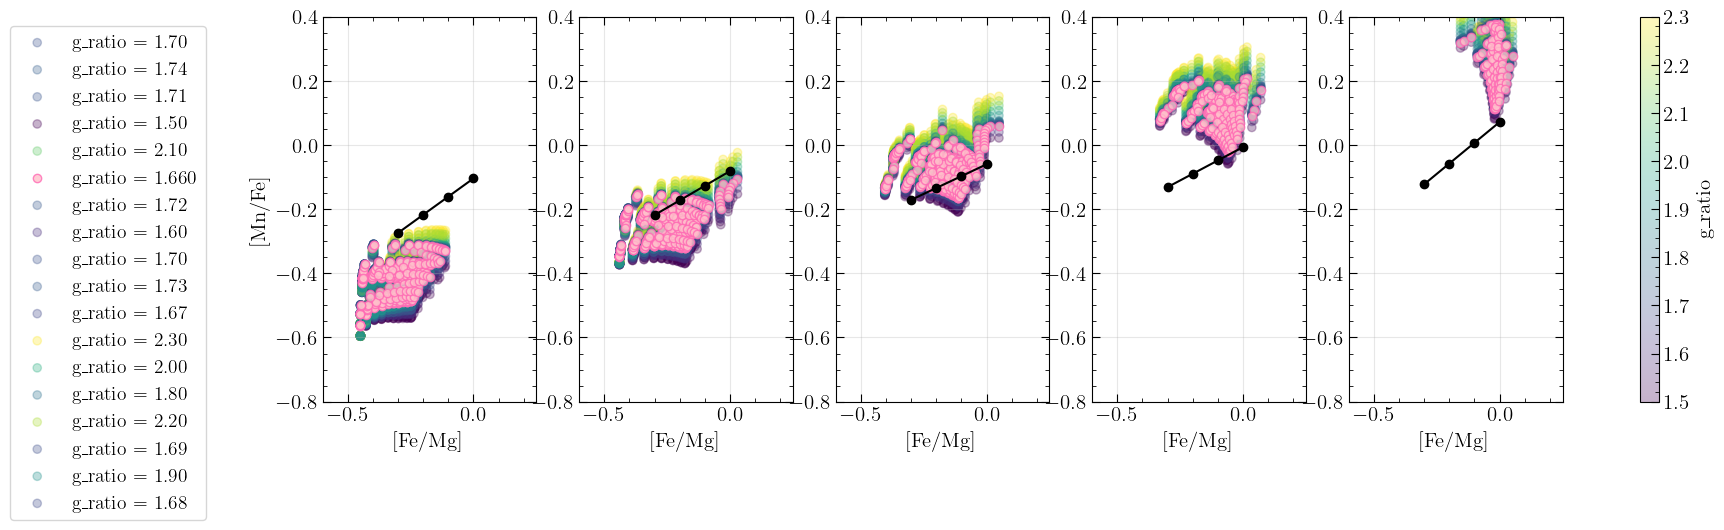

In [72]:
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="../outputs/unity_models_5")

# Models 6

 --alpha_cc 0.50 --alpha_Ia 0.40 --g_cc 0.40 --g_ratio 1.60 --save_dir "unity_models_6"

Extracted best_val for alpha_cc: 0.44


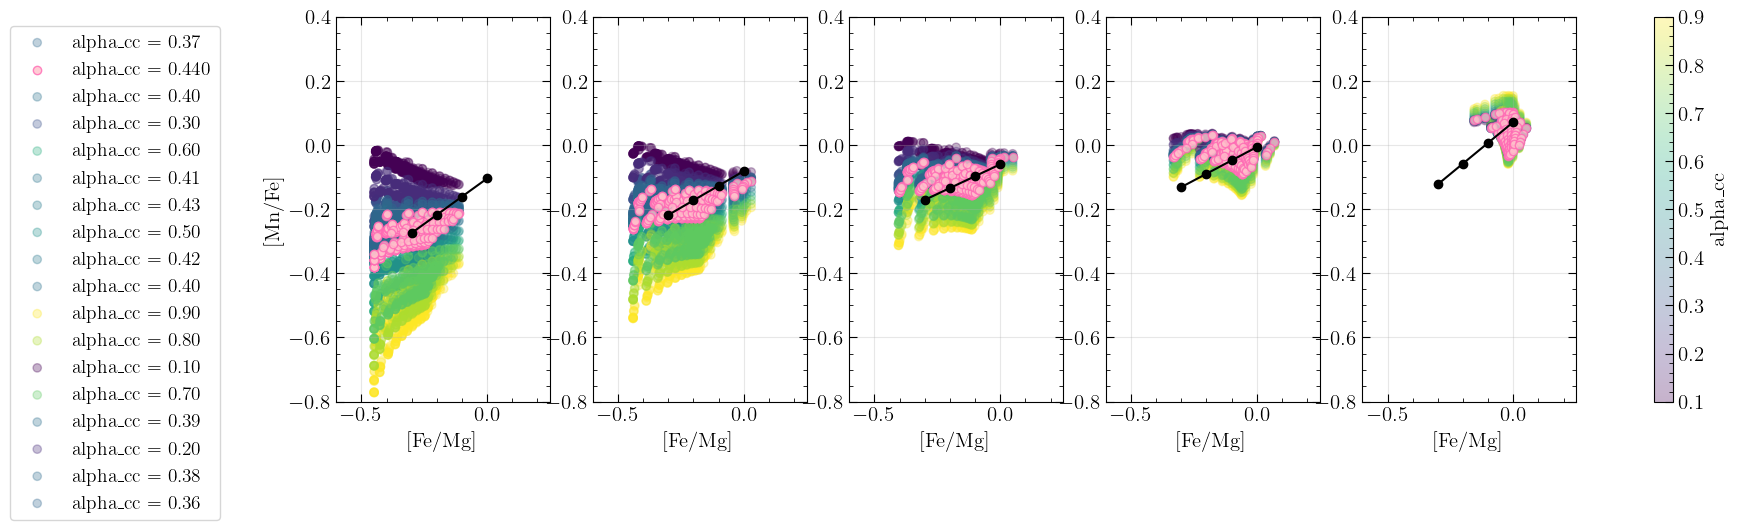

In [73]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="../outputs/unity_models_6")

Extracted best_val for alpha_Ia: 0.26


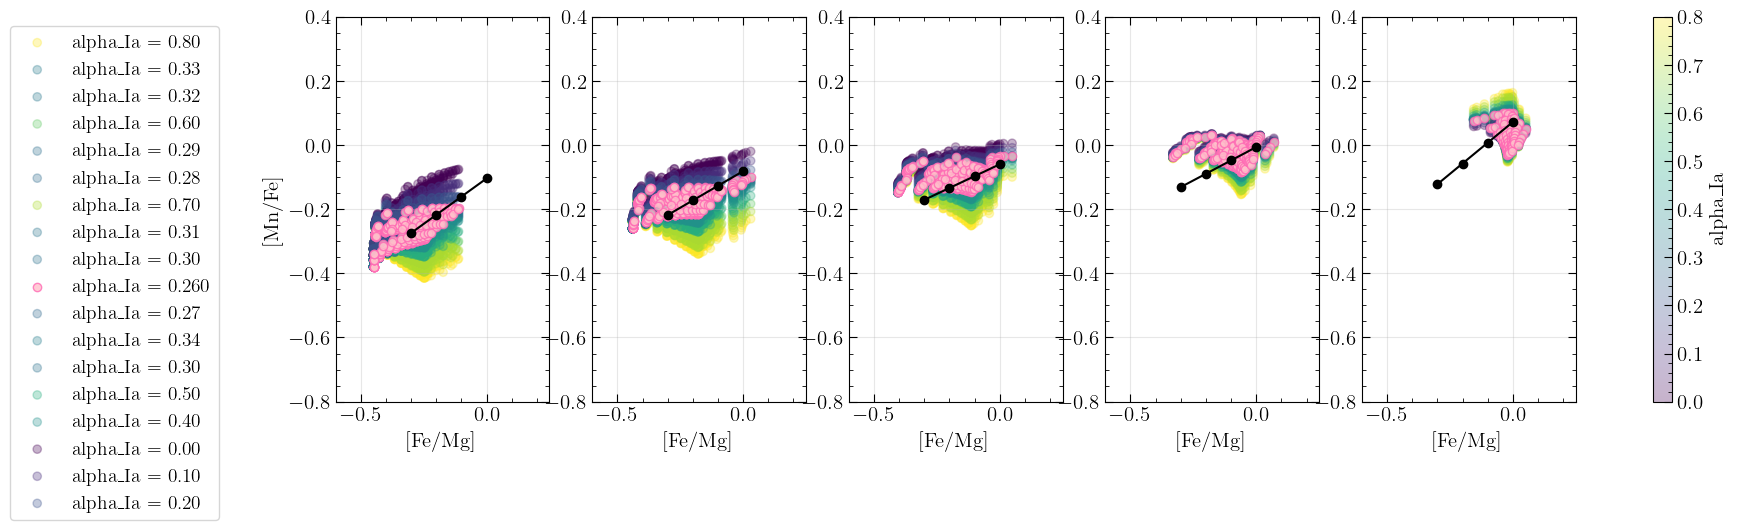

In [74]:
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="../outputs/unity_models_6")

Extracted best_val for g_cc: 0.39


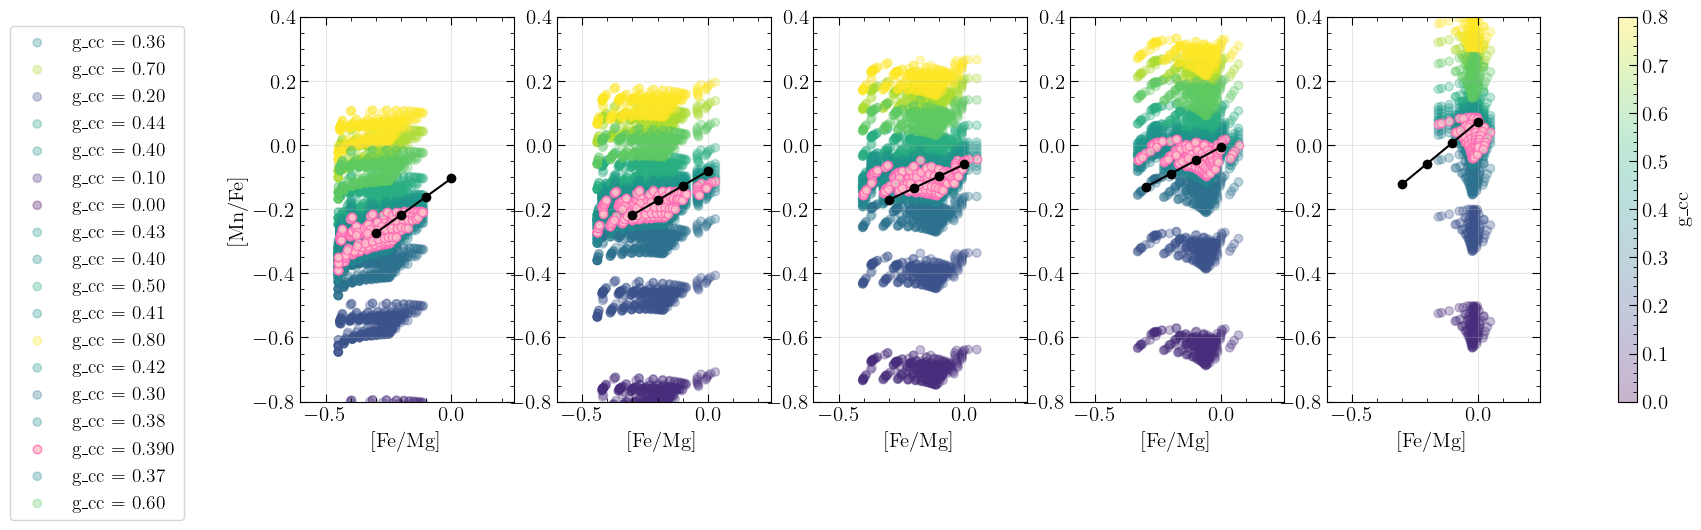

In [76]:
plot_mn_fe(param_to_plot="g_cc", models_files_dir="../outputs/unity_models_6")

Extracted best_val for g_ratio: 1.64


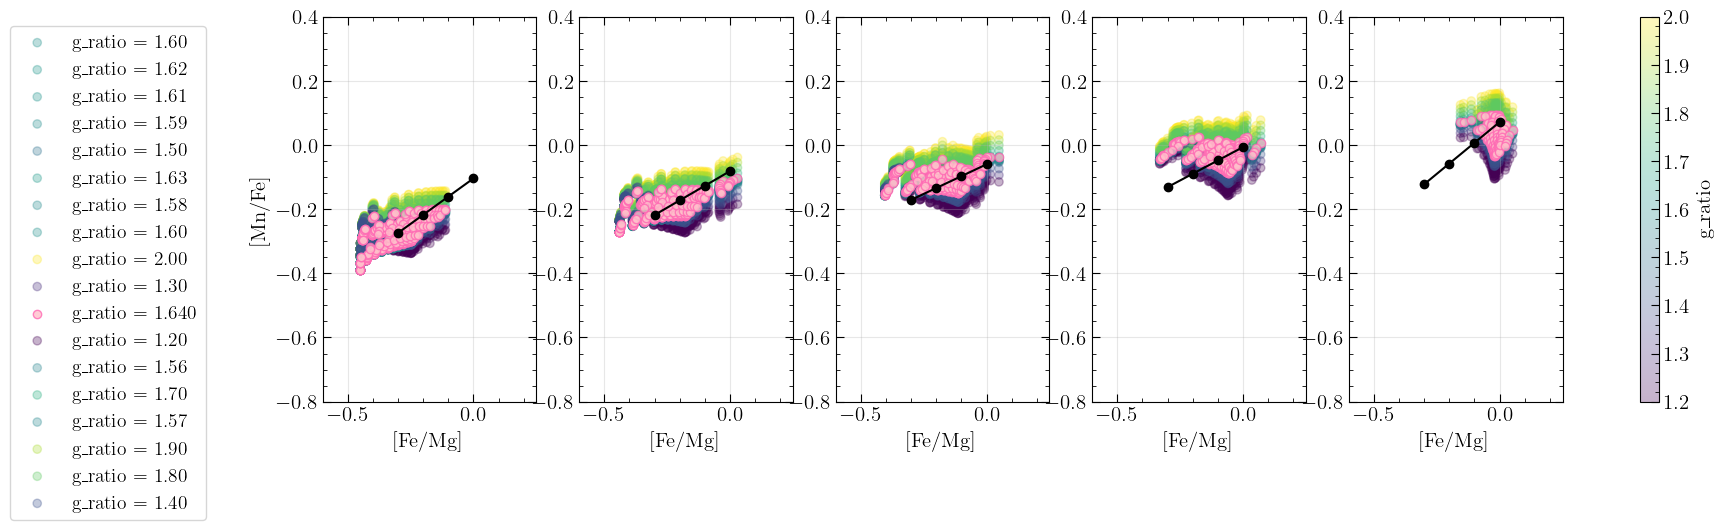

In [77]:
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="../outputs/unity_models_6")

# Models 7

--alpha_cc 0.50 --alpha_Ia 0.40 --g_cc 0.40 --g_ratio 2.2 --save_dir "unity_models_7"

Extracted best_val for alpha_cc: 0.46


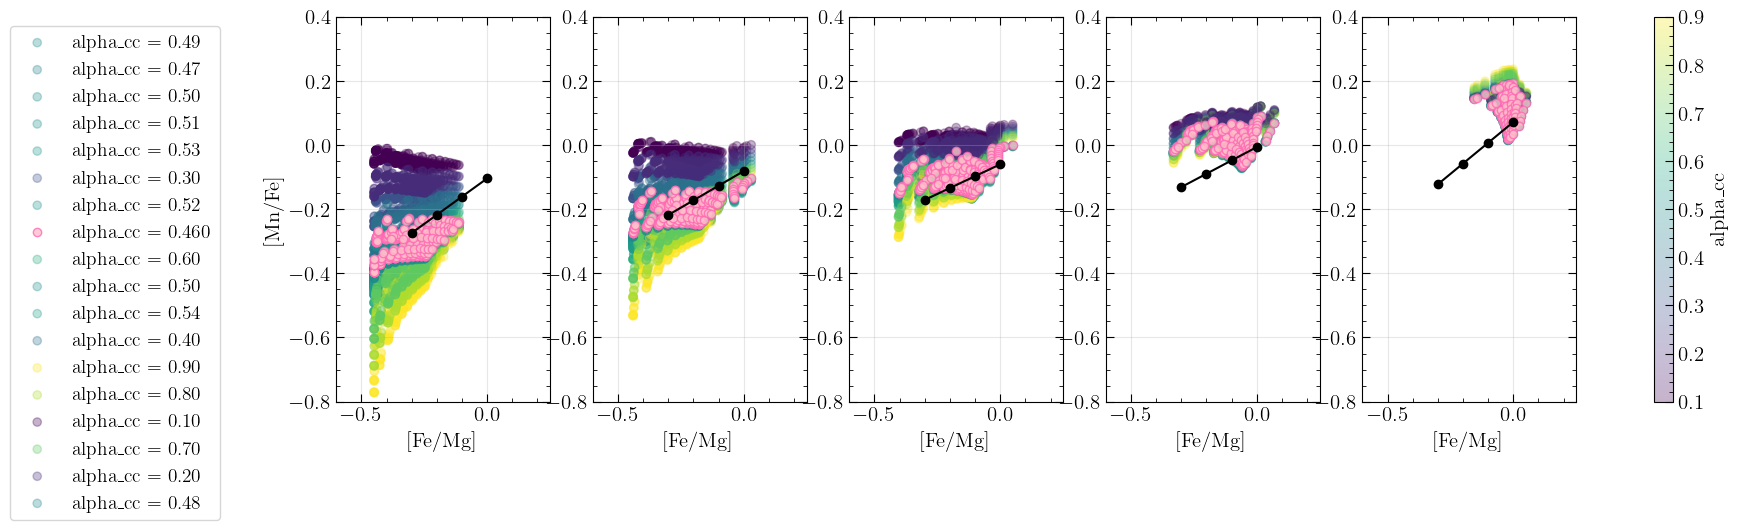

Extracted best_val for alpha_Ia: 0.46


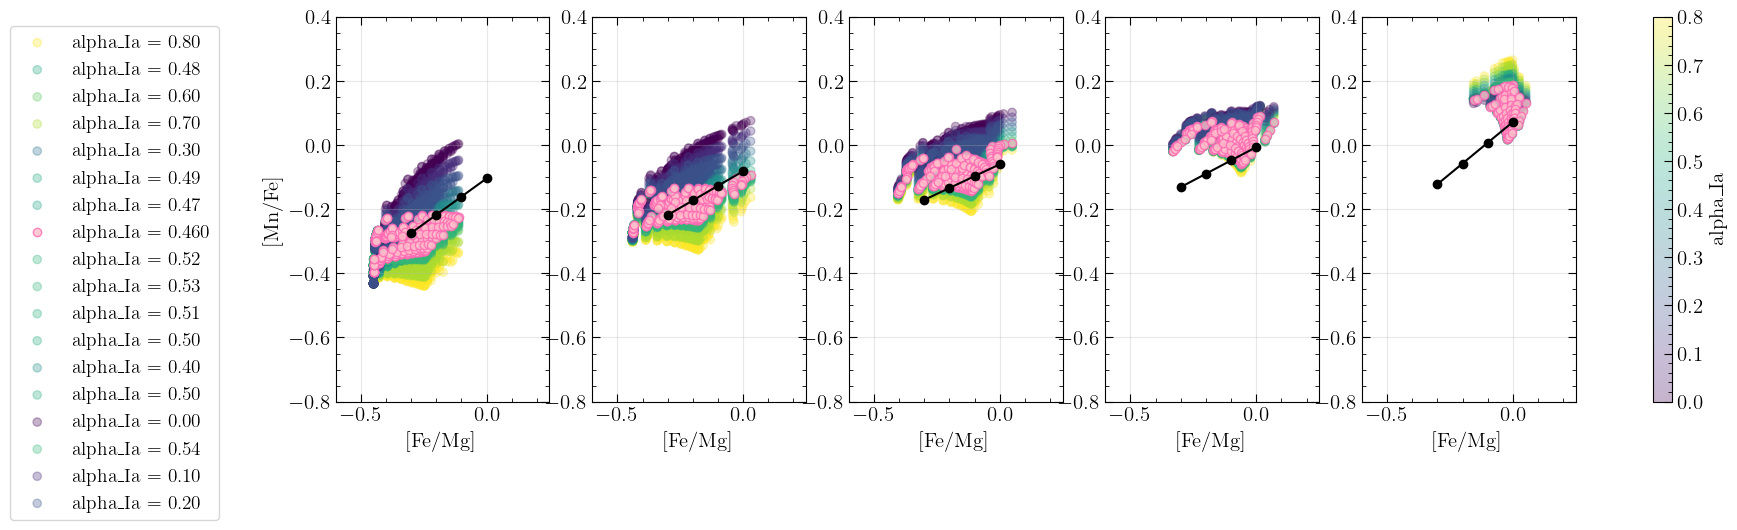

Extracted best_val for g_cc: 0.38


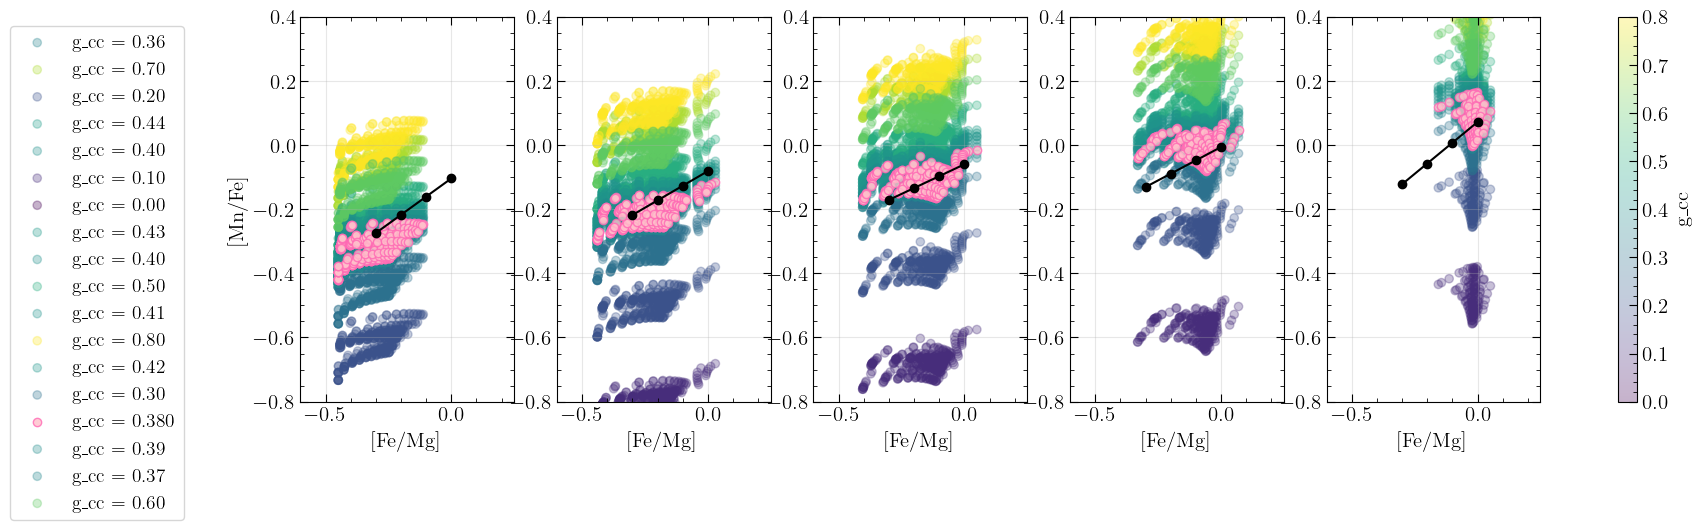

Extracted best_val for g_ratio: 2.04


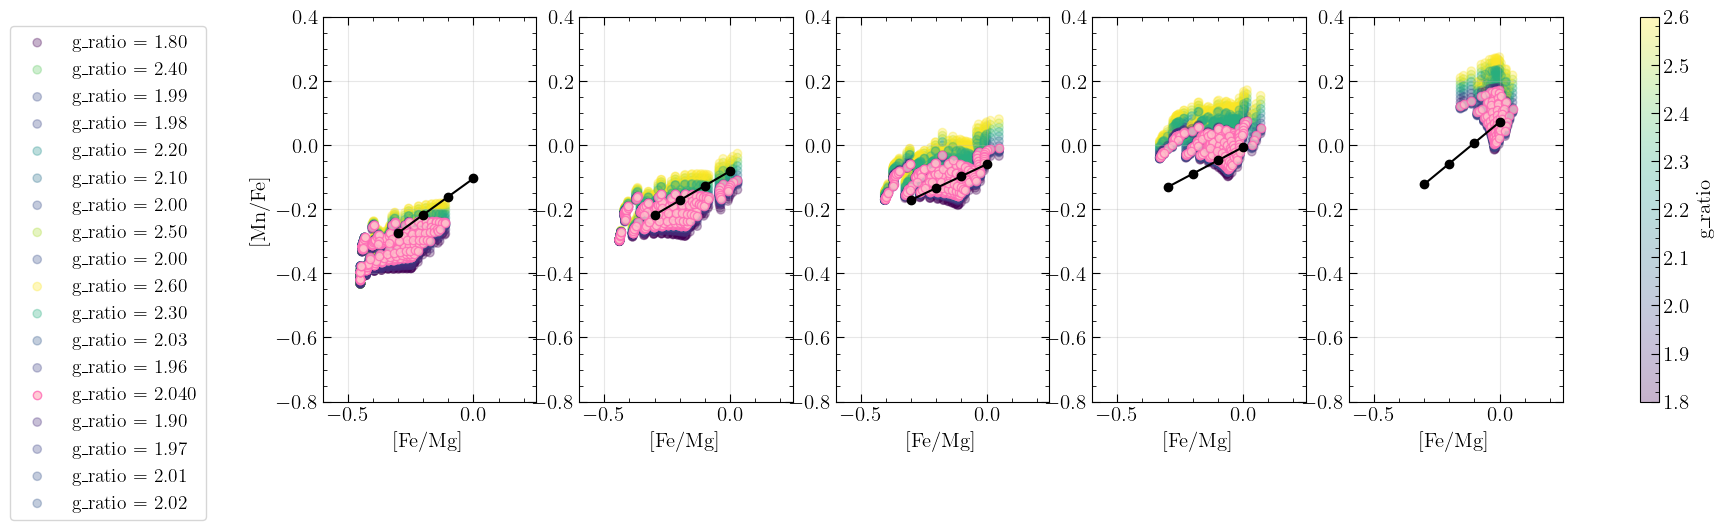

In [78]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="../outputs/unity_models_7")
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="../outputs/unity_models_7")
plot_mn_fe(param_to_plot="g_cc", models_files_dir="../outputs/unity_models_7")
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="../outputs/unity_models_7")

# Models 8

--alpha_cc 0.20 --alpha_Ia 0.80 --g_cc 0.20 --g_ratio 1.60 --save_dir "unity_models_8"

Extracted best_val for alpha_cc: -0.12


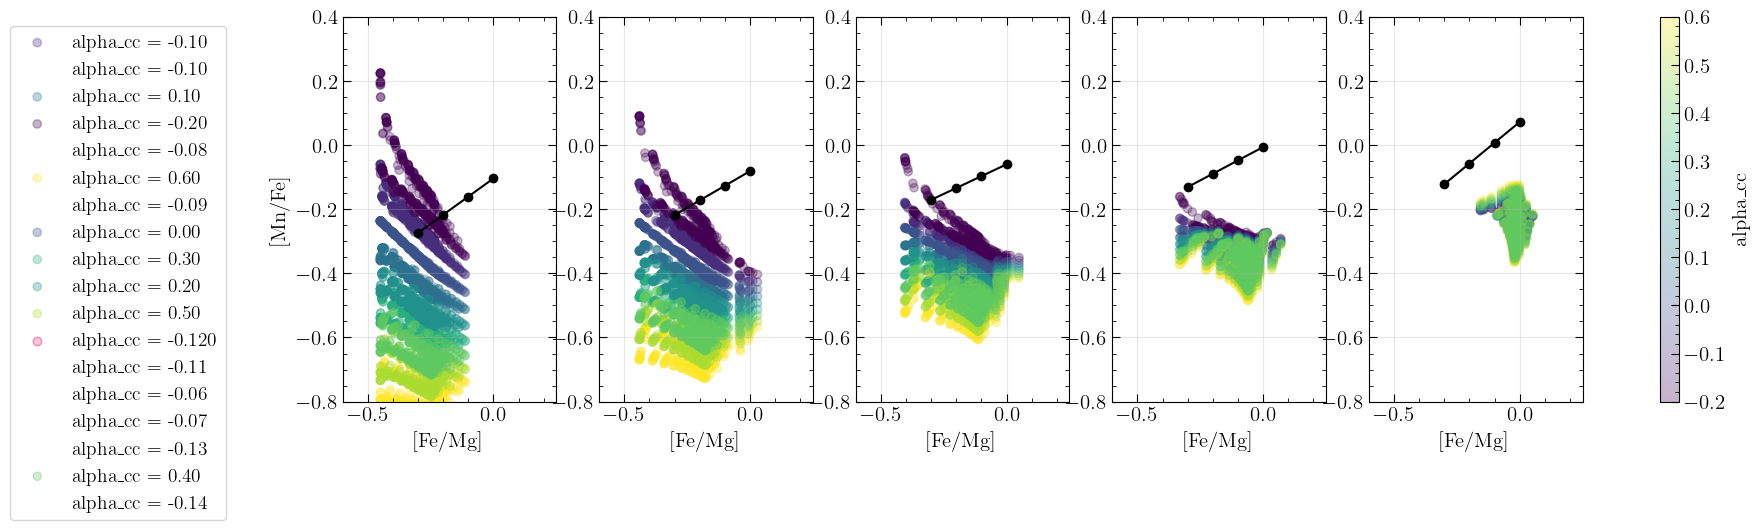

Extracted best_val for alpha_Ia: 0.44


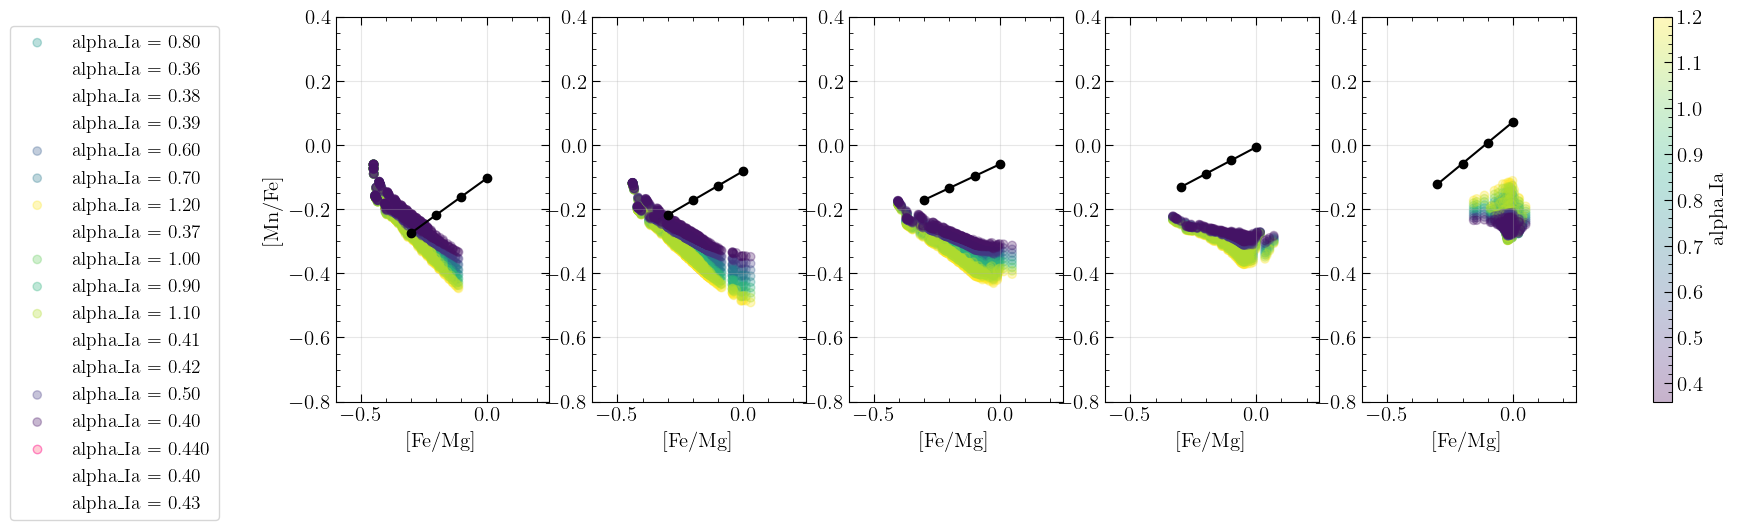

Extracted best_val for g_cc: -0.07


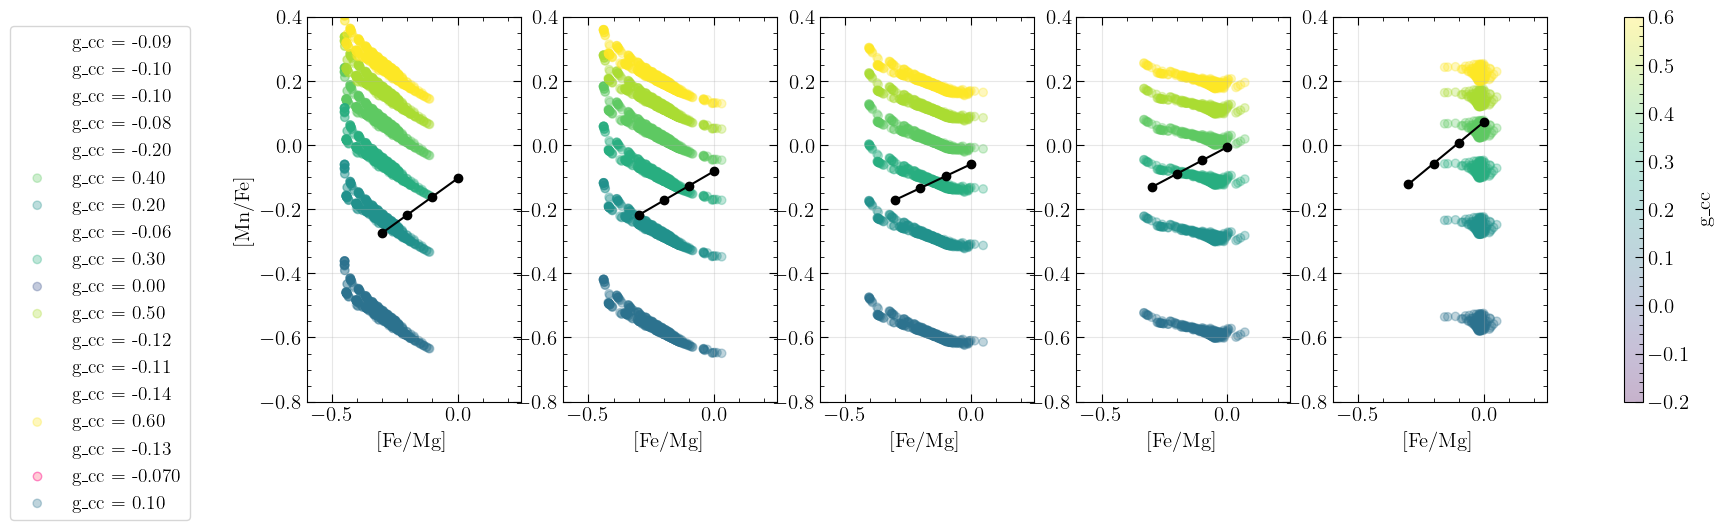

Extracted best_val for g_ratio: 1.77


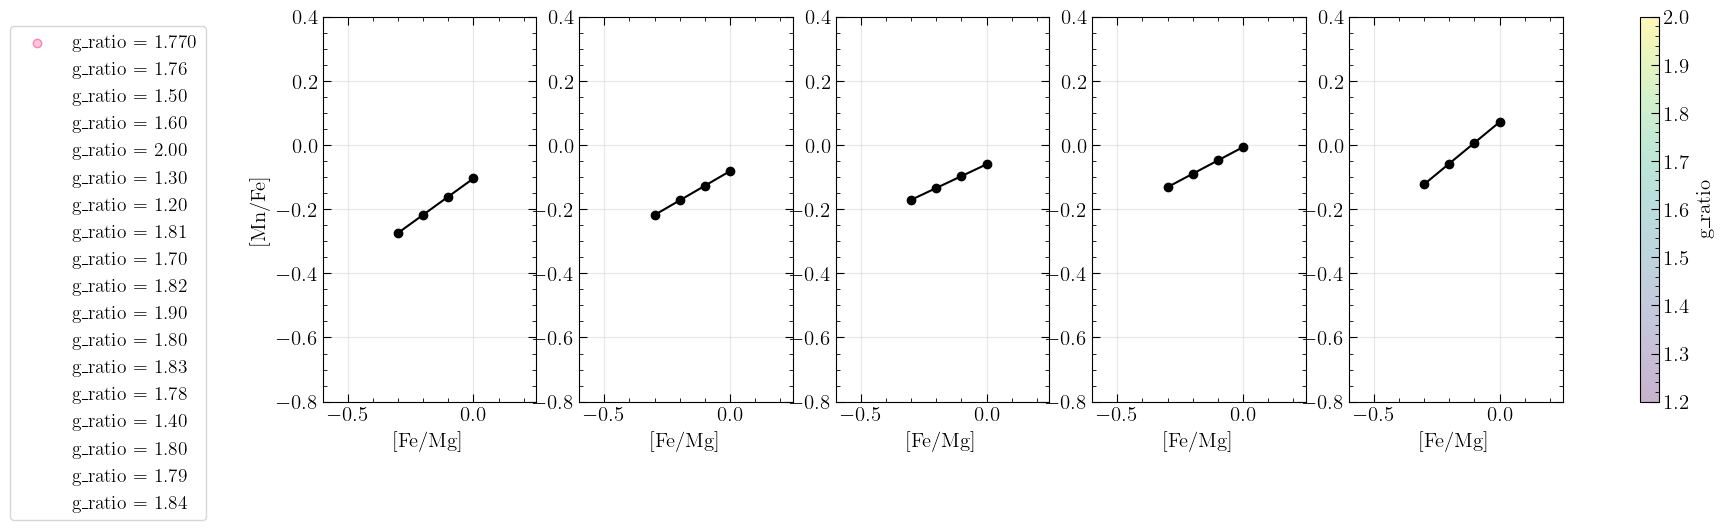

In [79]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="../outputs/unity_models_8")
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="../outputs/unity_models_8")
plot_mn_fe(param_to_plot="g_cc", models_files_dir="../outputs/unity_models_8")
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="../outputs/unity_models_8")

# Models 9
--alpha_cc 0.80 --alpha_Ia 0.30 --g_cc 0.60 --g_ratio 1.50 --save_dir "unity_models_9"

Extracted best_val for alpha_cc: 0.8600000000000001


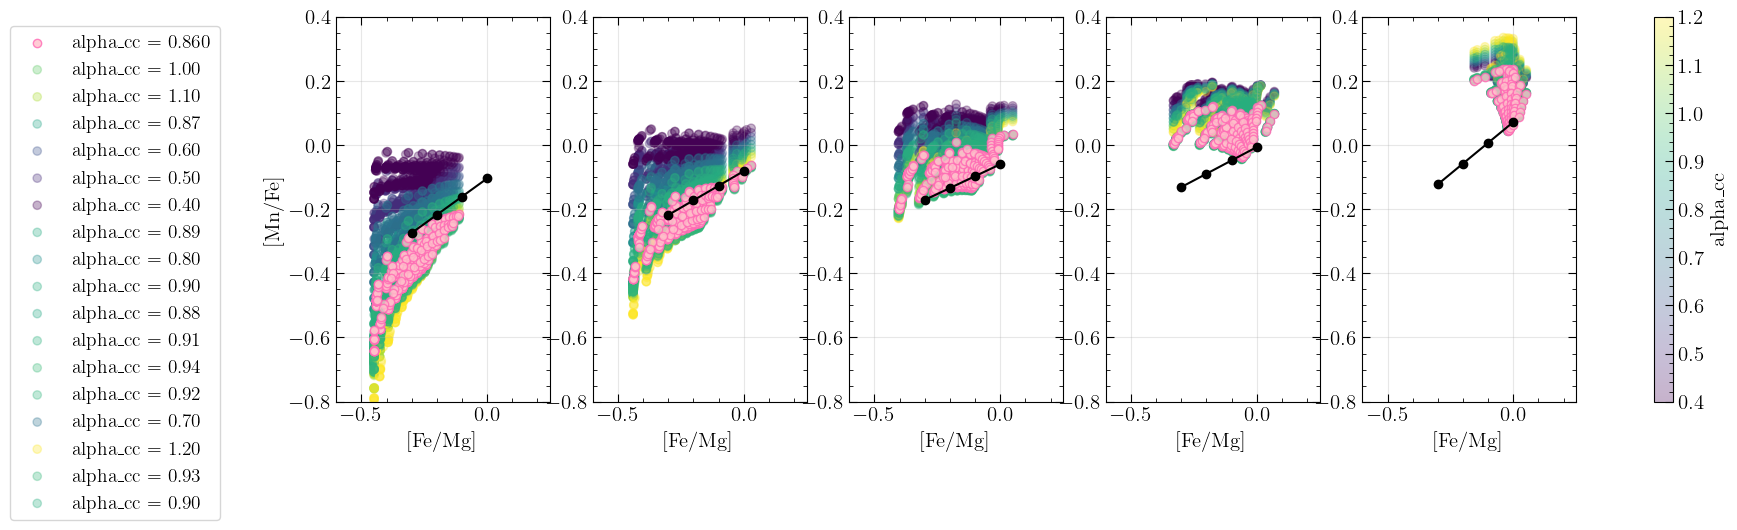

Extracted best_val for alpha_Ia: 0.26


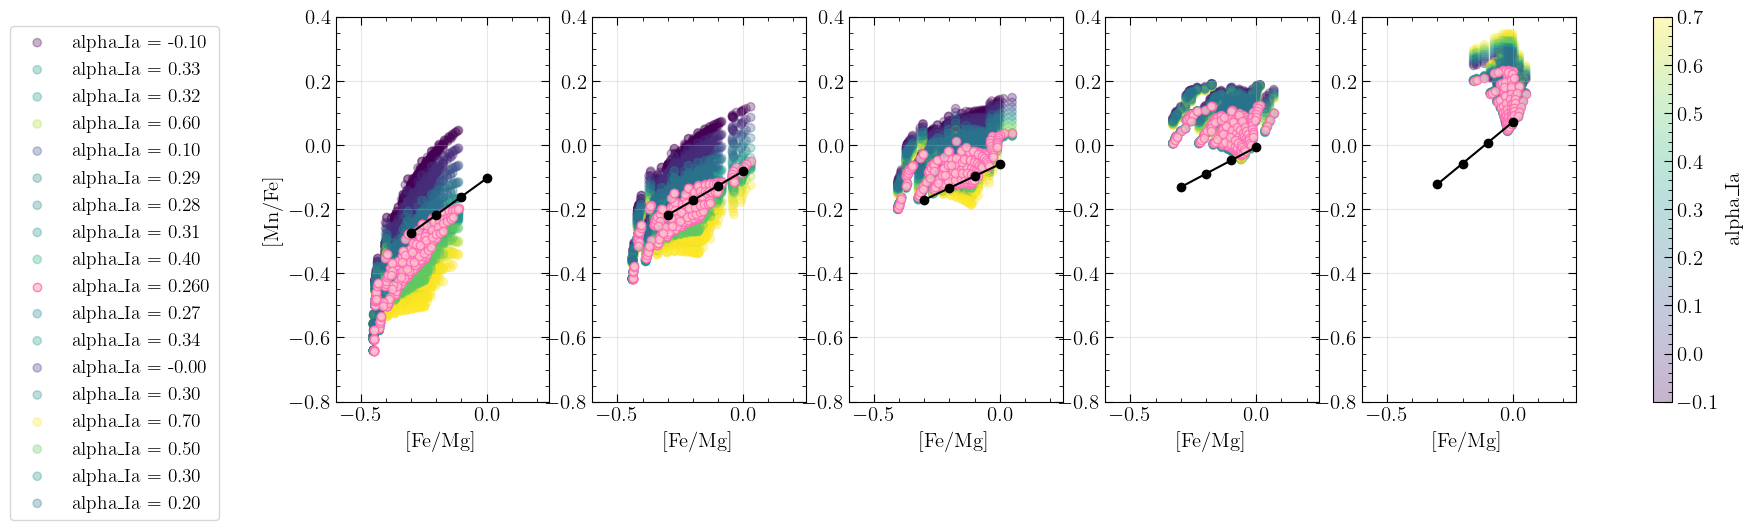

Extracted best_val for g_cc: 0.49


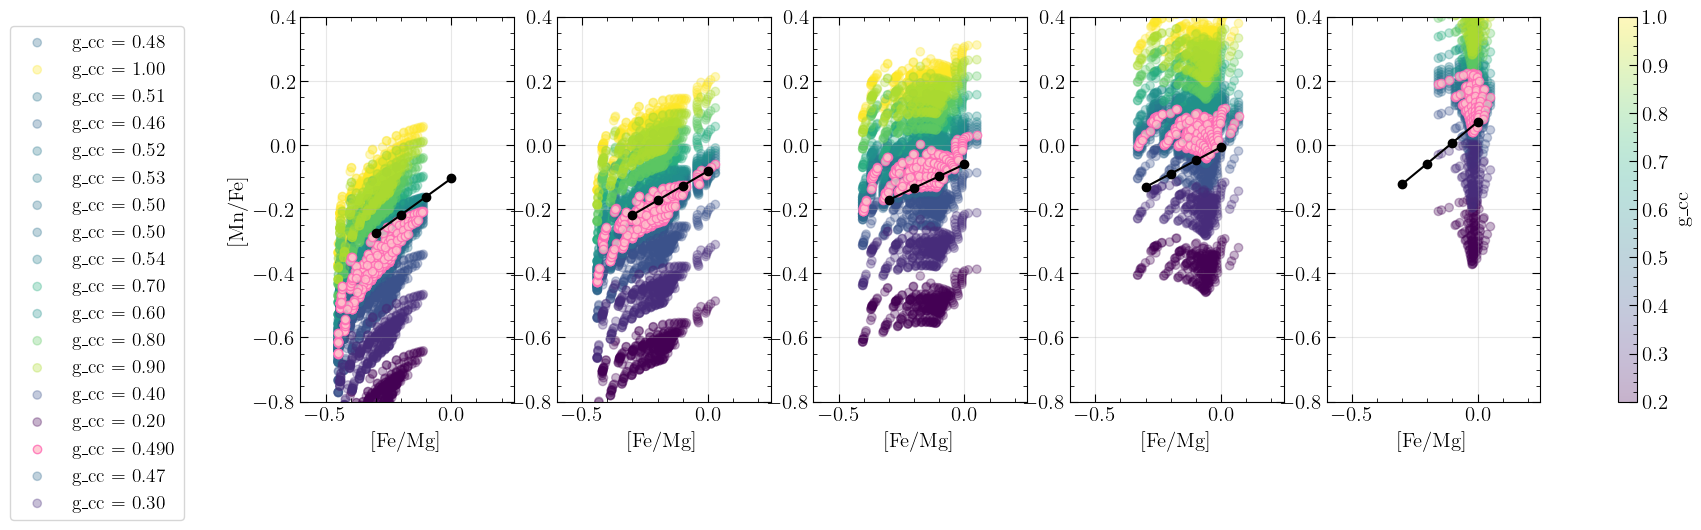

Extracted best_val for g_ratio: 1.58


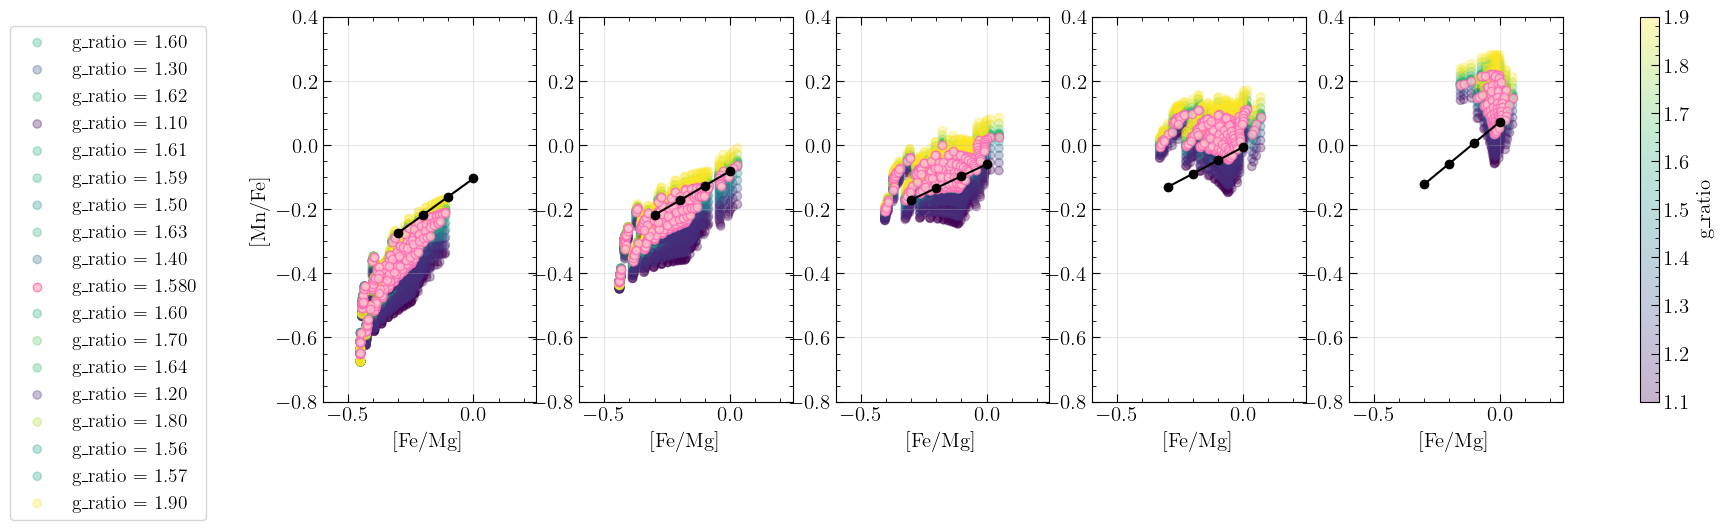

In [80]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="../outputs/unity_models_9")
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="../outputs/unity_models_9")
plot_mn_fe(param_to_plot="g_cc", models_files_dir="../outputs/unity_models_9")
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="../outputs/unity_models_9")

In [83]:
(2.898 * 10**-3)/(5800) / 10**(-9)

499.65517241379314